# Aprendizaje Federado con Gobernanza Institucional GRC para Deteccion de Intrusiones en Infraestructuras Criticas

---

## Identificacion del Proyecto

| Campo | Detalle |
|---|---|
| **Titulo** | Deteccion de intrusiones en redes mediante aprendizaje federado con Naive Bayes hibrido y Mixtura de Gaussianas, regularizado por variables de gobernanza institucional CRISC |
| **Codigo interno** | EJD-UMA-FedNB-GRC |
| **Version del notebook** | v1.0 |
| **Fecha de creacion** | 2026-03-09 |
| **Ultima modificacion** | 2026-05-10 |

---

## Contexto Academico

| Campo | Detalle |
|---|---|
| **Institucion** | Universidad de Malaga (UMA), Espana |
| **Programa** | Programa de Doctorado en Tecnologias Informaticas |
| **Escuela** | Escuela de Doctorado de la Universidad de Malaga |
| **Autor** | Edgar Oswaldo Herrera Logrono, M.Sc. en Inteligencia Artificial, VIU Espana |
| **Director de tesis** | Prof. Dr. Ezequiel Lopez Rubio, Dpto. de Lenguajes y Ciencias de la Computacion, UMA |
| **Tutor** | Prof. Dr. Juan Miguel Ortiz de Lazcano Lobato, Dpto. de Lenguajes y Ciencias de la Computacion, UMA |
| **Colaboracion** | NICS Lab, Universidad de Malaga |
| **Manuscrito** | https://www.overleaf.com/6315368384gjmfzrvskxxj#0018e4 |

---

## Hipotesis Principal

La ponderacion federada guiada por variables de gobernanza institucional derivadas del marco CRISC (CMM, KCI, KRI, CVSS) permite que el servidor de aprendizaje federado asigne mayor influencia a los nodos con mayor madurez de seguridad, mejorando el F1-macro de deteccion de intrusiones respecto al baseline de ponderacion proporcional (FedAvg), sin necesidad de compartir datos entre instituciones.

---

## Objetivo del Experimento

Demostrar que la Propuesta A (mezcla con pesos aprendidos por Nelder-Mead regularizados por ICC) supera a la Propuesta B (baseline FedAvg) en F1-macro sobre tres datasets de referencia en deteccion de intrusiones: NSL-KDD, CIC-IDS2017 y UNSW-NB15, evaluando ademas la alineacion entre los pesos aprendidos y el prior ICC derivado de variables CRISC.

---

## Ambiente de Ejecucion

| Parametro | Valor |
|---|---|
| **Entorno** | Google Colab (CPU/GPU) |
| **Lenguaje** | Python 3.10+ |
| **Semilla aleatoria** | 42 (critico para reproducibilidad) |
| **Split** | Entrenamiento 60% / Validacion 20% / Prueba 20% |
| **Repeticiones** | 5 por configuracion |
| **Niveles de heterogeneidad** | 7 alphas Dirichlet: 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0 |

---

## Resumen de Variables CRISC

Las variables de gobernanza institucional CRISC definen el Indice de Coherencia Contextual (ICC) de cada nodo:

**ICC = (CMM/5) x KCI x (1 - KRI) x (1 - CVSS/10)**

| Variable | Significado | Rango |
|---|---|---|
| CMM | Madurez del proceso de gestion de riesgos | 1 a 5 |
| KCI | Proporcion de controles de seguridad implementados | 0 a 1 |
| KRI | Frecuencia de activacion de alertas de riesgo (menor es mejor) | 0 a 1 |
| CVSS | Puntuacion media de vulnerabilidades CVSS v3.1 (menor es mejor) | 0 a 10 |

> **Nota de version:** En la fase inicial (6/abr/2026) se uso el termino FCI (Efectividad de Controles) como nombre provisional. El Prof. Lopez Rubio solicito sustituirlo por KRI y CVSS en v7.1 para ganar granularidad cientifica. Esta es la configuracion definitiva del preprint v2 (Seccion 3.3).

---

## Datasets Utilizados

| Dataset | Tipo | Registros | Clases |
|---|---|---|---|
| NSL-KDD | Trafico de red clasico | 147,888 | Binario (normal/ataque) |
| CIC-IDS2017 | Trafico moderno con ataques reales | 100,000 (submuestreo) | Binario (normal/ataque) |
| UNSW-NB15 | Trafico multiclase con 9 tipos de ataque | 257,673 | Multiclase (10 categorias) |

---

## Propuestas Evaluadas

| Codigo | Nombre | Descripcion |
|---|---|---|
| C | Centralizado | Un modelo unico con todos los datos. Techo teorico imposible en produccion. |
| B | Baseline FedAvg | Pesos proporcionales al tamano del dataset local. Punto de referencia estandar. |
| E | Mezcla por Entropia | Mayor peso al nodo con menor incertidumbre en sus predicciones. |
| A | Mezcla con ICC (CRISC) | Pesos aprendidos por Nelder-Mead regularizados por el prior ICC. Propuesta principal. |

---

**Orden obligatorio de ejecucion:** Kaggle > Sec.0 > Sec.1 > Sec.2 > Sec.3 > Sec.4 > Sec.5 > Sec.6 > Sec.7 > Sec.8 > Sec.9 > Protocolo-Stress > Resumen > Conclusiones

---
## Configuracion Kaggle
Ejecutar una sola vez antes de todo. Necesario para CIC-IDS2017 y UNSW-NB15.

In [18]:
import shutil, os
from pathlib import Path

ruta_kaggle = Path.home() / ".kaggle"
ruta_kaggle.mkdir(exist_ok=True)

if (ruta_kaggle / "kaggle.json").exists():
    (ruta_kaggle / "kaggle.json").chmod(0o600)
    print("[OK] kaggle.json ya configurado.")
else:
    print("Sube tu kaggle.json:")
    try:
        from google.colab import files
        archivos = files.upload()
        if "kaggle.json" in archivos:
            shutil.copy("kaggle.json", ruta_kaggle / "kaggle.json")
            (ruta_kaggle / "kaggle.json").chmod(0o600)
            print("[OK] kaggle.json configurado.")
    except ImportError:
        print("[!] Coloca kaggle.json en ~/.kaggle/ manualmente.")
print("[OK] Celda Kaggle ejecutada.")

[OK] kaggle.json ya configurado.
[OK] Celda Kaggle ejecutada.


---
## Seccion 0 - Parametros
Todo lo configurable esta aqui. Nada mas abajo tiene valores fijos.

In [19]:
VERSION = "EJD-UMA-FedNB-GRC-v1.0"
SEMILLA = 42
MODO_RAPIDO = False

# 7 niveles aprobados Prof. Lopez Rubio 20/abr/2026
NIVELES_ALPHA = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
REPETICIONES       = 1 if MODO_RAPIDO else 5
MUESTRAS_VAL_OPTIM = 500 if MODO_RAPIDO else 2000
LAMBDA_REG = 0.10  # elevado de 0.01: con ANLL normalizado en el optimizador
           # ambos terminos (ANLL y regularizacion) quedan en la misma
           # escala, haciendo que el prior ICC tenga peso real en la decision
PISO_W     = 0.05  # reducido de 0.10: permite al optimizador
           # reflejar mejor la jerarquia ICC real de cada nodo
           # aprobado por NotebookLM 10/may/2026 contra emails UMA
TOPE_CIC   = 100_000
MIN_MUESTRAS_CLASE = 5  # clases con menos registros se excluyen del split
PROP_VAL   = 0.20
PROP_TEST  = 0.20

# ICC = (CMM/5) * KCI * (1 - KRI) * (1 - CVSS/10)
# Fuente: EJD-UMA-FedNB-GRC -- valores verificados contra emails UMA abr/2026
NODOS_CRISC = {
    "Financiero": {"CMM": 4, "KCI": 0.82, "KRI": 0.12, "CVSS": 3.2},
    "Salud":      {"CMM": 3, "KCI": 0.70, "KRI": 0.25, "CVSS": 5.1},
    "Gobierno":   {"CMM": 2, "KCI": 0.55, "KRI": 0.40, "CVSS": 6.8},
}

def calcular_icc(cmm, kci, kri, cvss):
    return round((cmm / 5) * kci * (1 - kri) * (1 - cvss / 10), 3)

# Por que las variables CRISC aportan valor al experimento:
# Sin ICC (LAMBDA_REG=0) el optimizador daria pesos uniformes
# ~0.33 por nodo sin importar la madurez institucional.
# Con ICC como regularizador, el nodo de mayor madurez
# (Financiero, ICC=0.393) recibe el mayor peso aprendido
# y el de menor madurez (Gobierno, ICC=0.042) el menor.
# Ese diferencial es el aporte original: la gobernanza
# institucional CRISC guia la ponderacion federada.

for nombre_nodo, vars_nodo in NODOS_CRISC.items():
    vars_nodo["ICC"] = calcular_icc(
        vars_nodo["CMM"], vars_nodo["KCI"],
        vars_nodo["KRI"], vars_nodo["CVSS"])

NOMBRES_NODOS = list(NODOS_CRISC.keys())
ICC_POR_NODO  = [NODOS_CRISC[n]["ICC"] for n in NOMBRES_NODOS]
N_NODOS       = len(NOMBRES_NODOS)

print(f"Version  : {VERSION}")
print(f"Nodos    : {NOMBRES_NODOS}")
print(f"ICC      : {ICC_POR_NODO}")
print(f"Alphas   : {NIVELES_ALPHA}")
print(f"Reps     : {REPETICIONES} | Val optim: {MUESTRAS_VAL_OPTIM}")
print(f"Split    : train={1-PROP_VAL-PROP_TEST:.0%} val={PROP_VAL:.0%} test={PROP_TEST:.0%}")
print("[OK] Seccion 0 - parametros cargados.")

Version  : EJD-UMA-FedNB-GRC-v1.0
Nodos    : ['Financiero', 'Salud', 'Gobierno']
ICC      : [0.393, 0.154, 0.042]
Alphas   : [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
Reps     : 5 | Val optim: 2000
Split    : train=60% val=20% test=20%
[OK] Seccion 0 - parametros cargados.


---
## Seccion 1 - Entorno
Importaciones, carpetas, log de sesion y alertas sonoras.

In [20]:
import gc, time, warnings, logging, subprocess
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import requests
from scipy.optimize import minimize
from scipy.stats import chi2
from scipy.special import logsumexp
from scipy.spatial.distance import jensenshannon
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Audio, display
warnings.filterwarnings("ignore")
np.random.seed(SEMILLA)

marca_sesion = datetime.now().strftime("%Y%m%d_%H%M%S")
RUTAS = {
    "nsl":      Path("datos/nsl_kdd"),
    "cic":      Path("datos/cicids2017"),
    "unsw":     Path("datos/unsw_nb15"),
    "figuras":  Path("resultados/figuras"),
    "metricas": Path("resultados/metricas"),
    "logs":     Path("resultados/logs"),
}
for carpeta in RUTAS.values():
    carpeta.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(RUTAS["logs"] / f"sesion_{marca_sesion}.log"),
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt="%H:%M:%S",
)
bitacora = logging.getLogger("EJD_UMA")
bitacora.info(f"Inicio {marca_sesion}")

def alerta_exito():
    tasa = 22050
    sil = np.zeros(int(tasa * 0.08))
    t   = np.linspace(0, 0.20, int(tasa * 0.20), endpoint=False)
    b   = 0.4 * np.sin(2 * np.pi * 432 * t) * np.exp(-6 * t)
    display(Audio(np.concatenate([b, sil, b]), rate=tasa, autoplay=True))

def alerta_error():
    tasa = 22050
    sil  = np.zeros(int(tasa * 0.07))
    def tono(f):
        t = np.linspace(0, 0.18, int(tasa * 0.18), endpoint=False)
        return 0.4 * np.sin(2 * np.pi * f * t) * np.exp(-4 * t)
    display(Audio(np.concatenate([tono(440), sil, tono(330), sil, tono(220)]),
                  rate=tasa, autoplay=True))

print(f"Sesion: {marca_sesion}")
print("[OK] Seccion 1 - entorno preparado.")

Sesion: 20260511_005745
[OK] Seccion 1 - entorno preparado.


---
## Seccion 2 - Carga y limpieza
Descarga automatica NSL-KDD. CIC-IDS2017 desde Parquet. UNSW-NB15 desde CSV.

In [21]:
COLUMNAS_NSL = [
    "duracion","tipo_protocolo","servicio","bandera",
    "bytes_origen","bytes_destino","tierra","frag_incorrecto",
    "urgente","caliente","intentos_login_fallidos","sesion_iniciada",
    "num_comprometidos","shell_raiz","intento_su","num_raiz",
    "num_creacion_archivos","num_shells","num_archivos_acceso",
    "num_cmds_salida","login_host","login_invitado","conteo",
    "conteo_srv","tasa_serror","tasa_serror_srv","tasa_rerror",
    "tasa_rerror_srv","tasa_mismo_srv","tasa_diff_srv",
    "tasa_diff_host_srv","conteo_host_dst","conteo_srv_host_dst",
    "tasa_mismo_srv_host","tasa_diff_srv_host",
    "tasa_mismo_puerto_src","tasa_diff_host_srv_dst",
    "tasa_serror_host","tasa_serror_srv_host",
    "tasa_rerror_host","tasa_rerror_srv_host","etiqueta",
]
COLS_CAT_NSL  = ["tipo_protocolo", "servicio", "bandera"]
COLS_NUM_NSL  = [c for c in COLUMNAS_NSL
                 if c not in COLS_CAT_NSL + ["etiqueta"]]
COLS_CAT_CIC  = ["Protocol"]
COLS_CAT_UNSW = ["proto", "state", "service"]

EXCLUIR_CIC = {
    "Label","Flow ID","Source IP","Source Port",
    "Destination IP","Destination Port","Timestamp",
    "External IP","etiqueta"
}
EXCLUIR_UNSW = {
    "label","attack_cat","id","srcip","sport",
    "dstip","dsport","Stime","Ltime","etiqueta"
}

def kaggle_descargar(id_dataset, carpeta):
    # si ya hay archivos en la carpeta, no re-descarga
    if any(carpeta.glob("*.*")):
        return True
    try:
        subprocess.run(["pip","install","kaggle","-q"],
                       check=True, capture_output=True)
        res = subprocess.run(
            ["kaggle","datasets","download","-d",
             id_dataset,"--unzip","-p",str(carpeta)],
            capture_output=True, text=True, timeout=600)
        if res.returncode == 0:
            print(f"  Kaggle descargado: {id_dataset}")
            return True
        print(f"  [!] Kaggle error: {res.stderr[:200]}")
        return False
    except Exception as e:
        print(f"  [!] Kaggle fallo: {e}")
        return False

def descargar_url(url, ruta, timeout=90):
    if ruta.exists() and ruta.stat().st_size > 5000:
        return True
    try:
        r = requests.get(url, timeout=timeout, stream=True)
        r.raise_for_status()
        ruta.write_bytes(r.content)
        return True
    except Exception:
        return False

def cargar_nsl_kdd():
    arch_tr = RUTAS["nsl"] / "KDDTrain+.txt"
    arch_te = RUTAS["nsl"] / "KDDTest+.txt"
    for url in [
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt",
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt",
    ]:
        if descargar_url(url, arch_tr): break
    for url in [
        "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt",
        "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt",
    ]:
        if descargar_url(url, arch_te): break
    partes = []
    for arch in [arch_tr, arch_te]:
        if not arch.exists():
            raise FileNotFoundError(f"NSL-KDD no disponible: {arch}")
        df = pd.read_csv(arch, header=None,
                         names=COLUMNAS_NSL + ["dificultad"])
        df = df.drop(columns=["dificultad"], errors="ignore")
        df["etiqueta"] = df["etiqueta"].str.strip().str.rstrip(".")
        partes.append(df)
    return partes[0], partes[1]

def cargar_cicids2017():
    # Kaggle: dhoogla/cicids2017 (archivos Parquet por tipo de ataque)
    # Alternativa manual: https://www.unb.ca/cic/datasets/ids-2017.html
    kaggle_descargar("dhoogla/cicids2017", RUTAS["cic"])

    # buscar archivos Parquet (formato del dataset en Kaggle)
    parquets = sorted(RUTAS["cic"].glob("*.parquet"))
    if parquets:
        print(f"  Leyendo {len(parquets)} archivos Parquet CIC-IDS2017...")
        dfs = []
        for pq in parquets:
            df_pq = pd.read_parquet(pq)
            nombre = pq.stem.lower()
            # si no tiene columna Label, inferirla del nombre del archivo
            col_label = next(
                (c for c in df_pq.columns if c.strip().lower() == "label"),
                None)
            if col_label is None:
                df_pq["Label"] = "BENIGN" if "benign" in nombre \
                    else pq.stem.split("-")[0]
            elif col_label != "Label":
                df_pq = df_pq.rename(columns={col_label: "Label"})
            dfs.append(df_pq)
        df = pd.concat(dfs, ignore_index=True)
        print(f"  CIC-IDS2017 cargado: {len(df):,} registros")
        return df

    # buscar CSVs si no hay Parquet
    csvs = sorted(RUTAS["cic"].glob("*.csv"))
    if csvs:
        df = pd.concat([pd.read_csv(f, low_memory=False)
                        for f in csvs], ignore_index=True)
        return df

    raise FileNotFoundError(
        "[!] CIC-IDS2017 no encontrado.\n"
        "    Kaggle: dhoogla/cicids2017\n"
        "    Manual: https://www.unb.ca/cic/datasets/ids-2017.html")

def cargar_unsw_nb15():
    # Kaggle: mrwellsdavid/unsw-nb15
    # Alternativa: https://research.unsw.edu.au/projects/unsw-nb15-dataset
    kaggle_descargar("mrwellsdavid/unsw-nb15", RUTAS["unsw"])

    # nombres verificados del dataset en Kaggle
    candidatos_tr = [
        "UNSW_NB15_training-set.csv",
        "UNSW-NB15_training-set.csv",
        "UNSW_NB15.csv",
    ]
    candidatos_te = [
        "UNSW_NB15_testing-set.csv",
        "UNSW-NB15_testing-set.csv",
    ]
    arch_tr = next(
        (RUTAS["unsw"] / n for n in candidatos_tr
         if (RUTAS["unsw"] / n).exists()), None)
    if arch_tr is None:
        # buscar cualquier CSV grande disponible
        csvs = sorted(RUTAS["unsw"].glob("*.csv"),
                      key=lambda f: f.stat().st_size, reverse=True)
        csvs_datos = [f for f in csvs
                      if "feature" not in f.name.lower()
                      and "event" not in f.name.lower()
                      and f.stat().st_size > 1_000_000]
        if not csvs_datos:
            raise FileNotFoundError(
                "[!] UNSW-NB15 no encontrado.\n"
                "    Kaggle: mrwellsdavid/unsw-nb15\n"
                "    Manual: https://research.unsw.edu.au/projects/unsw-nb15-dataset")
        arch_tr = csvs_datos[0]
        print(f"  UNSW: usando {arch_tr.name}")

    df_tr = pd.read_csv(arch_tr, low_memory=False)
    arch_te = next(
        (RUTAS["unsw"] / n for n in candidatos_te
         if (RUTAS["unsw"] / n).exists()), None)
    df_te = pd.read_csv(arch_te, low_memory=False) if arch_te else None
    return df_tr, df_te

print("[OK] Seccion 2 - funciones de carga definidas.")

[OK] Seccion 2 - funciones de carga definidas.


In [22]:
def binarizar_etiqueta(serie):
    s = serie.astype(str).str.strip().str.lower()
    return (~s.isin(["normal", "benign", "0"])).astype(int)

def preparar_y_limpiar(datos_brutos, columna_etiqueta,
                        cols_cat, excluir_set, nombre_ds, modo="binario"):
    print(f"\n  --- Limpieza: {nombre_ds} ---")
    df = datos_brutos.copy()
    df.columns = df.columns.str.strip()
    columna_etiqueta = columna_etiqueta.strip()

    n_inicial = len(df)
    print(f"  Registros iniciales          : {n_inicial:,}")

    if columna_etiqueta not in df.columns:
        raise ValueError(
            f"Columna '{columna_etiqueta}' no encontrada. "
            f"Disponibles: {list(df.columns[:8])}")

    # UNSW-NB15: service puede tener "-" como valor valido, no es NaN
    for col_cat_esp in ["service", "proto", "state"]:
        if col_cat_esp in df.columns:
            df[col_cat_esp] = df[col_cat_esp].fillna("-").astype(str)

    if modo == "binario":
        df["etiqueta"] = binarizar_etiqueta(df[columna_etiqueta])
    else:
        df["etiqueta"] = df[columna_etiqueta].astype(str).str.strip()
        df = df[~df["etiqueta"].isin(["", "nan", "NaN"])]

    if columna_etiqueta != "etiqueta":
        df = df.drop(columns=[columna_etiqueta], errors="ignore")

    mascara_nula = df["etiqueta"].isna()
    if mascara_nula.any():
        df = df[~mascara_nula]
        print(f"  Eliminados etiqueta nula     : {mascara_nula.sum():,}")

    cols_cat_ok = [c for c in cols_cat if c in df.columns]
    cols_num_ok = [
        c for c in df.columns
        if c not in excluir_set
        and c not in cols_cat_ok
        and c != "etiqueta"
        and pd.api.types.is_numeric_dtype(df[c])
    ]

    # CIC-IDS2017: Flow Bytes/s y Flow Packets/s tienen infinitos reales
    for col_inf in ["Flow Bytes/s", "Flow Packets/s"]:
        if col_inf in df.columns:
            df[col_inf] = df[col_inf].replace([np.inf, -np.inf], np.nan)

    df[cols_num_ok] = df[cols_num_ok].replace([np.inf, -np.inf], np.nan)

    n_antes_dup = len(df)
    df = df.drop_duplicates()
    eliminados_dup = n_antes_dup - len(df)
    if eliminados_dup > 0:
        print(f"  Eliminados duplicados        : {eliminados_dup:,}")

    n_antes_nan = len(df)
    df = df.dropna(subset=cols_cat_ok + cols_num_ok + ["etiqueta"])
    eliminados_nan = n_antes_nan - len(df)
    if eliminados_nan > 0:
        print(f"  Eliminados NaN/Inf           : {eliminados_nan:,}")

    # eliminar clases con muy pocos registros para [revisado] el split
    conteo_clases = df["etiqueta"].value_counts()
    clases_validas = conteo_clases[conteo_clases >= MIN_MUESTRAS_CLASE].index
    n_antes_cls = len(df)
    df = df[df["etiqueta"].isin(clases_validas)].reset_index(drop=True)
    if len(df) < n_antes_cls:
        print(f"  Eliminados por clase escasa  : {n_antes_cls - len(df):,}")

    n_final = len(df)
    pct = 100 * n_final / n_inicial
    print(f"  Registros finales limpios    : {n_final:,} ({pct:.1f}%)")
    print(f"  Clases: {dict(df[chr(101)+chr(116)+chr(105)+chr(113)+chr(117)+chr(101)+chr(116)+chr(97)].value_counts().sort_index())}")

    return df, cols_cat_ok, cols_num_ok

def submuestreo_estratificado(df, tope, semilla):
    # Instruccion Prof. Lopez Rubio 26/abr/2026:
    # "mantener todas las muestras de las clases minoritarias"
    # Caso normal: clase mayorit. se recorta, minoritaria se preserva integra.
    # Caso especial: si la clase minoritaria ya supera el tope,
    # se subsamplea proporcionalmente para que ambas clases
    # tengan representacion suficiente para el split estratificado.
    if len(df) <= tope:
        return df
    clase_mayor = df["etiqueta"].value_counts().idxmax()
    df_min = df[df["etiqueta"] != clase_mayor]
    df_may = df[df["etiqueta"] == clase_mayor]
    cupo_may = tope - len(df_min)
    if cupo_may < MIN_MUESTRAS_CLASE:
        # la clase minoritaria supera el tope
        # subsampleo proporcional para llegar al tope manteniendo la razon
        prop_may = len(df_may) / len(df)
        n_may = max(MIN_MUESTRAS_CLASE, int(tope * prop_may))
        n_min = max(MIN_MUESTRAS_CLASE, tope - n_may)
        df_may_s = df_may.sample(
            n=min(n_may, len(df_may)), random_state=semilla)
        df_min_s = df_min.sample(
            n=min(n_min, len(df_min)), random_state=semilla)
        print(f"  Submuestreo proporcional (minoria > tope): "
              f"mayor={len(df_may_s):,} menor={len(df_min_s):,}")
    else:
        df_may_s = df_may.sample(
            n=min(cupo_may, len(df_may)), random_state=semilla)
        df_min_s = df_min
    resultado = (pd.concat([df_may_s, df_min_s])
                 .sample(frac=1, random_state=semilla)
                 .reset_index(drop=True))
    print(f"  Submuestreo: {len(df):,} -> {len(resultado):,} registros")
    return resultado

print("[OK] Seccion 2 - limpieza definida.")

[OK] Seccion 2 - limpieza definida.


---
## Seccion 3 - Auditoria de datos
Celda independiente. Verifica 5 puntos antes de entrenar.

In [23]:
def auditar_dataset(datos_limpios, cols_cat, cols_num, nombre):
    sep = "=" * 58
    print(sep)
    print(f"  AUDITORIA: {nombre}")
    print(sep)

    print("\n  [1] Distribucion de clases:")
    conteo = datos_limpios["etiqueta"].value_counts().sort_index()
    for clase, total in conteo.items():
        pct = 100 * total / len(datos_limpios)
        print(f"      Clase {str(clase):<20}: {total:,} ({pct:.1f}%)")

    print(f"\n  [2] Columnas:")
    print(f"      Categoricas ({len(cols_cat)}): {cols_cat}")
    print(f"      Numericas   ({len(cols_num)}): {cols_num[:4]} ...")

    nan_cat = datos_limpios[cols_cat].isna().sum().sum()
    nan_num = datos_limpios[cols_num].isna().sum().sum()
    inf_num = np.isinf(datos_limpios[cols_num].values.astype(float)).sum()
    print(f"\n  [3] NaN cat={nan_cat} | NaN num={nan_num} | Inf={inf_num}")
    if nan_cat + nan_num + inf_num > 0:
        print("      [!] ALERTA: hay valores problematicos")

    print(f"\n  [4] Cardinalidad categoricas:")
    for col in cols_cat:
        n_u = datos_limpios[col].nunique()
        mues = list(datos_limpios[col].unique()[:4])
        print(f"      {col:<15}: {n_u} valores. Muestra: {mues}")

    print(f"\n  [5] Clases por nodo (alpha=0.1, muestra 2000):")
    mues_aud = datos_limpios.sample(
        min(2000, len(datos_limpios)), random_state=SEMILLA)
    clases_g = sorted(mues_aud["etiqueta"].unique())
    for idx_n in range(N_NODOS):
        idx_nodo = []
        for c in clases_g:
            idx_c = mues_aud[mues_aud["etiqueta"] == c].index.tolist()
            gen_tmp = np.random.default_rng(SEMILLA + idx_n)
            props = gen_tmp.dirichlet([0.1] * N_NODOS)
            corte = int(props[idx_n] * len(idx_c))
            idx_nodo.extend(idx_c[:corte])
        cls_nodo = (mues_aud.loc[idx_nodo, "etiqueta"].unique()
                    if idx_nodo else [])
        nota = "" if len(idx_nodo) > 0 else " (normal a alpha=0.1 alta heterogeneidad)"
        print(f"      {NOMBRES_NODOS[idx_n]:<14}: "
              f"{len(idx_nodo)} muestras | clases: {sorted(cls_nodo)}{nota}")
    print(sep)

print("[OK] Seccion 3 - auditoria definida.")

[OK] Seccion 3 - auditoria definida.


---
## Seccion 4 - Protocolo de Verificacion
Detiene el programa si algun parametro no coincide con fuentes primarias.

In [24]:
sep = "=" * 58
print(sep)
print("  PROTOCOLO-VERIFICACION")
print(sep)
problemas = []

ref_icc = {"Financiero": 0.393, "Salud": 0.154, "Gobierno": 0.042}
for nombre_n, icc_esp in ref_icc.items():
    v = NODOS_CRISC[nombre_n]
    icc_cal = calcular_icc(v["CMM"], v["KCI"], v["KRI"], v["CVSS"])
    ok = abs(icc_cal - icc_esp) < 0.001
    print(f"  [{"OK" if ok else "FALLO"}] ICC {nombre_n}: calculado={icc_cal} ref={icc_esp}")
    if not ok: problemas.append(f"ICC {nombre_n}")

ok_a = (len(NIVELES_ALPHA)==7 and NIVELES_ALPHA==sorted(NIVELES_ALPHA))
print(f"  [{"OK" if ok_a else "FALLO"}] 7 alphas: {NIVELES_ALPHA}")
if not ok_a: problemas.append("Alphas")

np.random.seed(SEMILLA); a1=np.random.rand(10)
np.random.seed(SEMILLA); a2=np.random.rand(10)
ok_s = np.allclose(a1,a2)
print(f"  [{"OK" if ok_s else "FALLO"}] Semilla {SEMILLA} reproducible")
if not ok_s: problemas.append("Semilla")

ok_sp = (PROP_VAL+PROP_TEST) < 1.0
print(f"  [{"OK" if ok_sp else "FALLO"}] Split train={1-PROP_VAL-PROP_TEST:.0%} val={PROP_VAL:.0%} test={PROP_TEST:.0%}")
if not ok_sp: problemas.append("Split")

print(sep)
if problemas:
    alerta_error()
    raise RuntimeError(f"Protocolo-Verificacion: {problemas}. Corregir en Sec.0.")
print("  PROTOCOLO-VERIFICACION APROBADO")
print(sep)
print("[OK] Seccion 4 - verificacion exitosa.")

  PROTOCOLO-VERIFICACION
  [OK] ICC Financiero: calculado=0.393 ref=0.393
  [OK] ICC Salud: calculado=0.154 ref=0.154
  [OK] ICC Gobierno: calculado=0.042 ref=0.042
  [OK] 7 alphas: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  [OK] Semilla 42 reproducible
  [OK] Split train=60% val=20% test=20%
  PROTOCOLO-VERIFICACION APROBADO
[OK] Seccion 4 - verificacion exitosa.


---
## Seccion 5 - Preprocesado hibrido
CategoricalNB para nominales, GaussianNB para numericas. Fix np.clip aplicado.

In [25]:
class PreprocesadorHibrido:
    # encoder ajustado SOLO sobre train para evitar data leakage
    # OOD va al slot n_cats[j], nunca a n_cats[j]-1
    # Correccion Prof. Ortiz de Lazcano 7/may/2026

    def __init__(self, cols_cat, cols_num):
        self.cols_cat  = cols_cat
        self.cols_num  = cols_num
        self.codificador = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1, dtype=np.float64)
        self.escalador = StandardScaler()
        self.n_cats_tr = None
        self.clases    = None

    def ajustar_transformar(self, df_tr):
        mat_cat = df_tr[self.cols_cat].astype(str).values
        mat_num = df_tr[self.cols_num].values.astype(np.float64)
        etiq    = df_tr["etiqueta"].values
        mat_cat_cod = self.codificador.fit_transform(mat_cat).astype(int)
        mat_num_esc = self.escalador.fit_transform(mat_num)
        self.n_cats_tr = [len(c) for c in self.codificador.categories_]
        self.clases    = np.unique(etiq)
        return mat_cat_cod, mat_num_esc, etiq

    def transformar(self, df):
        mat_cat = df[self.cols_cat].astype(str).values
        mat_num = df[self.cols_num].values.astype(np.float64)
        etiq    = df["etiqueta"].values
        mat_cat_cod = self.codificador.transform(mat_cat)
        for j, n in enumerate(self.n_cats_tr):
            # -1 = OOD segun OrdinalEncoder -> asignar al slot n (extra)
            ood = mat_cat_cod[:, j] < 0
            mat_cat_cod[ood, j] = n
        mat_num_esc = self.escalador.transform(mat_num)
        return mat_cat_cod.astype(int), mat_num_esc, etiq


class NaiveBayesHibrido:
    # P(x|c) = P_cat(x_cual|c) * P_gauss(x_num|c)
    # Slot OOD activo desde entrenar() via min_categories
    # Correccion double prior: restar class_log_prior_ una vez

    def __init__(self, suavizado=1.0):
        self.suavizado = suavizado
        self.nb_cat = self.nb_gauss = None
        self.n_cats = self.clases = None

    def entrenar(self, cat, num, etiq):
        self.n_cats = [
            int(cat[:, j].max()) + 1
            for j in range(cat.shape[1])]
        self.nb_cat = CategoricalNB(
            alpha=self.suavizado,
            min_categories=[n+1 for n in self.n_cats])
        self.nb_cat.fit(cat, etiq)
        self.nb_gauss = GaussianNB()
        self.nb_gauss.fit(num, etiq)
        self.clases = self.nb_cat.classes_
        return self

    def _mapear_ood(self, cat):
        mat = cat.astype(float).copy()
        for j, n in enumerate(self.n_cats):
            col = mat[:, j]
            col = np.maximum(col, 0)
            col = np.where(col >= n, n, col)
            mat[:, j] = col
        return mat.astype(int)

    def log_verosimilitud(self, cat, num):
        lp_cat   = self.nb_cat.predict_log_proba(self._mapear_ood(cat))
        lp_num   = self.nb_gauss.predict_log_proba(num)
        lp_prior = self.nb_cat.class_log_prior_
        # restar prior una vez para evitar double-counting
        return lp_cat + lp_num - lp_prior

    def predecir(self, cat, num):
        return self.clases[
            np.argmax(self.log_verosimilitud(cat, num), axis=1)]

    def predecir_proba(self, cat, num):
        lp = self.log_verosimilitud(cat, num)
        lp -= lp.max(axis=1, keepdims=True)
        p   = np.exp(lp)
        return p / p.sum(axis=1, keepdims=True)


def dividir_estratificado(df, semilla):
    df_tr, df_tmp = train_test_split(
        df, test_size=PROP_VAL+PROP_TEST,
        stratify=df["etiqueta"], random_state=semilla)
    df_val, df_te = train_test_split(
        df_tmp, test_size=PROP_TEST/(PROP_VAL+PROP_TEST),
        stratify=df_tmp["etiqueta"], random_state=semilla)
    return df_tr, df_val, df_te

print("[OK] Seccion 5 - preprocesado hibrido definido.")

[OK] Seccion 5 - preprocesado hibrido definido.


---
## Seccion 6 - Modelo federado y servidor MoG
Distribucion Dirichlet por clase. 4 propuestas C/B/E/A.

In [26]:
def repartir_dirichlet(df_entreno, num_nodos, alpha, semilla):
    # distribucion por clase para mantener representacion en todos los nodos
    gen = np.random.default_rng(semilla)
    clases = sorted(df_entreno["etiqueta"].unique())
    partes = [[] for _ in range(num_nodos)]
    for c in clases:
        idx_c = df_entreno[df_entreno["etiqueta"]==c].index.tolist()
        gen.shuffle(idx_c)
        props  = gen.dirichlet([alpha]*num_nodos)
        cortes = (np.cumsum(props)*len(idx_c)).astype(int)
        inicio = 0
        for k, fin in enumerate(cortes):
            partes[k].extend(idx_c[inicio:fin])
            inicio = fin
    return [df_entreno.loc[p].reset_index(drop=True)
            for p in partes if len(p) > 1]


def js_entre_nodos(particiones):
    clases = sorted(set().union(
        *[set(p["etiqueta"].unique()) for p in particiones]))
    distribs = []
    for parte in particiones:
        frec = parte["etiqueta"].value_counts(normalize=True)
        distribs.append([frec.get(c,0) for c in clases])
    pares = [(i,j) for i in range(len(distribs))
             for j in range(i+1,len(distribs))]
    return np.mean([jensenshannon(distribs[i],distribs[j])
                    for i,j in pares])


def entrenar_modelos_locales(particiones, preprocesador):
    modelos, tamanos = [], []
    for parte in particiones:
        cat, num, etiq = preprocesador.transformar(parte)
        if len(np.unique(etiq)) < 2:
            continue
        m = NaiveBayesHibrido()
        m.entrenar(cat, num, etiq)
        modelos.append(m)
        tamanos.append(len(etiq))
    return modelos, np.array(tamanos)


def log_prob_servidor_mog(modelos, pesos, cat, num):
    # MoG real: no promedia parametros, combina densidades
    # mandato Prof. Lopez Rubio 16/abr/2026
    n_clases_ref = len(modelos[0].clases)
    lps = []
    for m in modelos:
        if len(m.clases) == n_clases_ref:
            lps.append(m.log_verosimilitud(cat, num))
    if not lps:
        return modelos[0].log_verosimilitud(cat, num)
    lps  = np.array(lps)
    pesos_validos = np.array(pesos[:len(lps)])
    pesos_validos = pesos_validos / pesos_validos.sum()
    logw = np.log(np.maximum(pesos_validos, 1e-10))[:,None,None]
    lw   = lps + logw
    mx   = lw.max(axis=0)
    return mx + np.log(np.exp(lw-mx).sum(axis=0))


def pesos_baseline(tamanos):
    return tamanos / tamanos.sum()


def pesos_por_entropia(modelos, cat_val, num_val):
    entropias = []
    for m in modelos:
        p = m.predecir_proba(cat_val, num_val)
        entropias.append(-np.sum(p*np.log(p+1e-10),axis=1).mean())
    inv = 1.0 / (np.array(entropias)+1e-10)
    return inv / inv.sum()


def proyectar_simplex(pesos_raw, piso):
    pesos = np.maximum(pesos_raw, piso)
    return pesos / pesos.sum()


def _objetivo(log_pesos, modelos, cat, num, etiq, icc_norm, lam):
    try:
        w_exp = np.exp(log_pesos - log_pesos.max())
        pesos  = proyectar_simplex(w_exp/w_exp.sum(), PISO_W)
        lp     = log_prob_servidor_mog(modelos, pesos, cat, num)
        # aplicar log-softmax para que ANLL y regularizacion esten en la
        # misma escala numerica (0 a log(n_clases) por muestra)
        # sin esto el ANLL domina en millones y el prior ICC es invisible
        lp_n   = lp - logsumexp(lp, axis=1, keepdims=True)
        mapa   = {c:i for i,c in enumerate(modelos[0].clases)}
        idx_y  = np.array([mapa.get(v,0) for v in etiq])
        anll   = -np.mean(lp_n[np.arange(len(etiq)), idx_y])
        reg    = lam * np.sum((pesos-icc_norm[:len(pesos)])**2)
        return anll + reg
    except Exception:
        return 1e10


def aprender_pesos_propuesta_A(modelos, cat_val, num_val, etiq_val,
                               icc_nodos, semilla):
    n = len(modelos)
    icc_norm = np.array(icc_nodos[:n])
    icc_norm = icc_norm / icc_norm.sum()
    gen = np.random.default_rng(semilla)

    # submuestreo para evitar timeout en Colab
    if len(etiq_val) > MUESTRAS_VAL_OPTIM:
        sel = gen.choice(len(etiq_val), MUESTRAS_VAL_OPTIM, replace=False)
        cat_v, num_v, etiq_v = (cat_val[sel], num_val[sel], etiq_val[sel])
    else:
        cat_v, num_v, etiq_v = cat_val, num_val, etiq_val

    puntos = [
        np.ones(n)/n,
        icc_norm.copy(),
        gen.dirichlet([1.0]*n),
        gen.dirichlet([0.5]*n),
        gen.dirichlet([2.0]*n),
    ]
    mejor_costo = np.inf
    mejor_log_w = np.log(icc_norm+1e-8)
    for punto in puntos:
        v = np.maximum(punto[:n], 1e-8)
        v = v / v.sum()
        res = minimize(
            _objetivo, np.log(v),
            args=(modelos, cat_v, num_v, etiq_v, icc_norm, LAMBDA_REG),
            method="Nelder-Mead",
            options={"maxiter":500,"xatol":1e-5,"fatol":1e-5})
        if res.fun < mejor_costo:
            mejor_costo = res.fun
            mejor_log_w = res.x
    w_exp = np.exp(mejor_log_w - mejor_log_w.max())
    return proyectar_simplex(w_exp/w_exp.sum(), PISO_W)

print("[OK] Seccion 6 - modelo federado y servidor MoG definidos.")

[OK] Seccion 6 - modelo federado y servidor MoG definidos.


---
## Seccion 7 - Metricas
F1-macro, ANLL con normalizacion log-softmax, McNemar.

In [27]:
def calcular_anll(log_prob, etiquetas, clases):
    # normalizar a log-probabilidades propias antes de calcular ANLL
    # evita que el ANLL sea negativo cuando log_verosimilitud devuelve
    # valores no normalizados (post-fix double prior)
    lp_norm = log_prob - logsumexp(log_prob, axis=1, keepdims=True)
    mapa  = {c:i for i,c in enumerate(clases)}
    idx_y = np.array([mapa.get(v,0) for v in etiquetas])
    return -np.mean(lp_norm[np.arange(len(etiquetas)), idx_y])


def test_mcnemar(etiq_real, pred_A, pred_B):
    b = np.sum((pred_A==etiq_real) & (pred_B!=etiq_real))
    c = np.sum((pred_A!=etiq_real) & (pred_B==etiq_real))
    n = b + c
    if n == 0:
        return 0.0, 1.0
    estadistico = (abs(b-c)-1.0)**2 / n
    return round(float(estadistico),2), round(
        float(1-chi2.cdf(estadistico,df=1)),4)


def evaluar_propuesta(modelos, pesos, cat_te, num_te, etiq_te):
    lp     = log_prob_servidor_mog(modelos, pesos, cat_te, num_te)
    clases = modelos[0].clases
    pred   = clases[np.argmax(lp, axis=1)]
    anll   = calcular_anll(lp, etiq_te, clases)
    f1     = f1_score(etiq_te, pred, average="macro", zero_division=0)
    return pred, anll, f1

print("[OK] Seccion 7 - metricas definidas.")

[OK] Seccion 7 - metricas definidas.


---
## Seccion 8 - Experimento multi-dataset
NSL-KDD, CIC-IDS2017 y UNSW-NB15 en secuencia.

In [28]:
def correr_experimento(datos_limpios, cols_cat, cols_num,
                        nombre_ds, n_reps=REPETICIONES):
    tabla = []
    sep = "=" * 58
    t_inicio = time.time()

    print(f"\n{sep}")
    print(f"  Dataset: {nombre_ds} | {len(datos_limpios):,} registros")
    print(f"  Reps: {n_reps} | Alphas: {NIVELES_ALPHA}")
    print(sep)

    auditar_dataset(datos_limpios, cols_cat, cols_num, nombre_ds)
    print(f"\n  Propuestas evaluadas en este experimento:")
    print(f"    C (Centralizado)   : un modelo con todos los datos - techo teorico")
    print(f"    B (Baseline FedAvg): pesos proporcionales al tamano del nodo")
    print(f"    E (Entropia)       : mas peso al nodo mas seguro en sus predicciones")
    print(f"    A (Mezcla ICC)     : pesos aprendidos usando variables CRISC como prior")

    for rep in range(n_reps):
        semilla_rep = SEMILLA + rep
        np.random.seed(semilla_rep)
        df_tr, df_val, df_te = dividir_estratificado(
            datos_limpios, semilla_rep)

        prep = PreprocesadorHibrido(cols_cat, cols_num)
        cat_tr,  num_tr,  etiq_tr  = prep.ajustar_transformar(df_tr)
        cat_val, num_val, etiq_val = prep.transformar(df_val)
        cat_te,  num_te,  etiq_te  = prep.transformar(df_te)

        # propuesta C: centralizado (techo teorico)
        modelo_c = NaiveBayesHibrido()
        modelo_c.entrenar(cat_tr, num_tr, etiq_tr)
        lp_C    = modelo_c.log_verosimilitud(cat_te, num_te)
        pred_C  = modelo_c.predecir(cat_te, num_te)
        anll_C  = calcular_anll(lp_C, etiq_te, modelo_c.clases)
        f1_C    = f1_score(etiq_te, pred_C, average="macro", zero_division=0)

        for alpha in NIVELES_ALPHA:
            particiones = repartir_dirichlet(df_tr, N_NODOS, alpha, semilla_rep)
            if len(particiones) < 2:
                continue
            js_valor = js_entre_nodos(particiones)
            modelos, tamanos = entrenar_modelos_locales(particiones, prep)
            if len(modelos) < 2:
                continue

            pw_B = pesos_baseline(tamanos[:len(modelos)])
            pw_E = pesos_por_entropia(modelos, cat_val, num_val)
            pw_A = aprender_pesos_propuesta_A(
                modelos, cat_val, num_val, etiq_val,
                ICC_POR_NODO, semilla_rep)

            pred_B, anll_B, f1_B = evaluar_propuesta(
                modelos, pw_B, cat_te, num_te, etiq_te)
            pred_E, anll_E, f1_E = evaluar_propuesta(
                modelos, pw_E, cat_te, num_te, etiq_te)
            pred_A, anll_A, f1_A = evaluar_propuesta(
                modelos, pw_A, cat_te, num_te, etiq_te)

            mc_chi2, mc_p = test_mcnemar(etiq_te, pred_A, pred_B)

            fila_base = {
                "dataset": nombre_ds, "rep": rep,
                "alpha": alpha, "js": round(float(js_valor),4),
            }
            for prop, anll_v, f1_v, pred_v, pw_v in [
                ("C", anll_C, f1_C, pred_C, None),
                ("B", anll_B, f1_B, pred_B, pw_B),
                ("E", anll_E, f1_E, pred_E, pw_E),
                ("A", anll_A, f1_A, pred_A, pw_A),
            ]:
                tabla.append({**fila_base,
                    "propuesta":  prop,
                    "anll":       round(float(anll_v),4),
                    "f1":         round(float(f1_v),4),
                    "pesos_vec":  pw_v.tolist() if pw_v is not None else None,
                    "mc_chi2": mc_chi2 if prop=="A" else None,
                    "mc_p":    mc_p    if prop=="A" else None,
                })

        t_rep = time.time() - t_inicio
        print(f"  rep {rep+1}/{n_reps} | alpha={NIVELES_ALPHA[-1]} | "
              f"C(central)={f1_C:.4f} B(base)={f1_B:.4f} "
              f"E(entrop)={f1_E:.4f} A(aprend)={f1_A:.4f} | "
              f"t={t_rep:.0f}s", flush=True)

    t_total = time.time() - t_inicio
    print(f"\n  Tiempo total {nombre_ds}: {t_total:.0f}s")
    return pd.DataFrame(tabla)

print("[OK] Seccion 8 - funcion de experimento definida.")

[OK] Seccion 8 - funcion de experimento definida.


In [29]:
estado_datasets = {}
todos_resultados = []
modelo_ej = prep_ej = datos_ej = cols_num_ej = None

# ── NSL-KDD ──────────────────────────────────────────────────────
try:
    df_tr_nsl, df_te_nsl = cargar_nsl_kdd()
    df_nsl_bruto = pd.concat([df_tr_nsl, df_te_nsl], ignore_index=True)
    df_nsl_bruto["etiqueta"] = binarizar_etiqueta(df_nsl_bruto["etiqueta"])
    datos_nsl, cols_cat_nsl, cols_num_nsl = preparar_y_limpiar(
        df_nsl_bruto, "etiqueta", COLS_CAT_NSL, set(), "NSL-KDD")
    res_nsl = correr_experimento(
        datos_nsl, cols_cat_nsl, cols_num_nsl, "NSL-KDD")
    todos_resultados.append(res_nsl)
    estado_datasets["NSL-KDD"] = "OK"
    # guardar para figuras de densidad
    df_tr_ej, _, _ = dividir_estratificado(datos_nsl, SEMILLA)
    prep_ej = PreprocesadorHibrido(cols_cat_nsl, cols_num_nsl)
    cat_ej, num_ej, etiq_ej = prep_ej.ajustar_transformar(
        df_tr_ej.sample(min(3000,len(df_tr_ej)), random_state=SEMILLA))
    modelo_ej = NaiveBayesHibrido().entrenar(cat_ej, num_ej, etiq_ej)
    datos_ej  = datos_nsl.sample(min(2000,len(datos_nsl)), random_state=SEMILLA)
    cols_num_ej = cols_num_nsl
    alerta_exito()
except Exception as exc:
    estado_datasets["NSL-KDD"] = f"FALLO: {exc}"
    print(f"[!] NSL-KDD: {exc}")
    alerta_error()
finally:
    gc.collect()

# ── CIC-IDS2017 ───────────────────────────────────────────────────
try:
    df_cic_bruto = cargar_cicids2017()
    datos_cic, cols_cat_cic, cols_num_cic = preparar_y_limpiar(
        df_cic_bruto, "Label",
        COLS_CAT_CIC, EXCLUIR_CIC, "CIC-IDS2017", modo="binario")
    datos_cic = submuestreo_estratificado(datos_cic, TOPE_CIC, SEMILLA)
    res_cic = correr_experimento(
        datos_cic, cols_cat_cic, cols_num_cic, "CIC-IDS2017")
    todos_resultados.append(res_cic)
    estado_datasets["CIC-IDS2017"] = "OK"
    alerta_exito()
except FileNotFoundError as exc:
    estado_datasets["CIC-IDS2017"] = "NO DISPONIBLE"
    print(f"[!] {exc}")
except Exception as exc:
    estado_datasets["CIC-IDS2017"] = f"FALLO: {exc}"
    print(f"[!] CIC-IDS2017: {exc}")
    alerta_error()
finally:
    gc.collect()

# ── UNSW-NB15 ─────────────────────────────────────────────────────
try:
    df_unsw_tr, df_unsw_te = cargar_unsw_nb15()
    df_unsw_bruto = pd.concat(
        [df_unsw_tr] + ([df_unsw_te] if df_unsw_te is not None else []),
        ignore_index=True)
    datos_unsw, cols_cat_unsw, cols_num_unsw = preparar_y_limpiar(
        df_unsw_bruto, "attack_cat",
        COLS_CAT_UNSW, EXCLUIR_UNSW, "UNSW-NB15", modo="multiclase")
    res_unsw = correr_experimento(
        datos_unsw, cols_cat_unsw, cols_num_unsw, "UNSW-NB15")
    todos_resultados.append(res_unsw)
    estado_datasets["UNSW-NB15"] = "OK"
    alerta_exito()
except FileNotFoundError as exc:
    estado_datasets["UNSW-NB15"] = "NO DISPONIBLE"
    print(f"[!] {exc}")
except Exception as exc:
    estado_datasets["UNSW-NB15"] = f"FALLO: {exc}"
    print(f"[!] UNSW-NB15: {exc}")
    alerta_error()
finally:
    gc.collect()

if todos_resultados:
    df_global = pd.concat(todos_resultados, ignore_index=True)
    df_global.to_csv(
        RUTAS["metricas"] / "resultados_globales.csv", index=False)
    print(f"\nResultados: {len(df_global)} filas | "
          f"Datasets: {df_global[chr(100)+chr(97)+chr(116)+chr(97)+chr(115)+chr(101)+chr(116)].unique().tolist()}")
else:
    df_global = pd.DataFrame()
    print("[!] Ningun dataset ejecutado.")

print("[OK] Seccion 8 - experimento completado.")


  --- Limpieza: NSL-KDD ---
  Registros iniciales          : 148,517
  Eliminados duplicados        : 629
  Registros finales limpios    : 147,888 (99.6%)
  Clases: {0: np.int64(76967), 1: np.int64(70921)}

  Dataset: NSL-KDD | 147,888 registros
  Reps: 5 | Alphas: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  AUDITORIA: NSL-KDD

  [1] Distribucion de clases:
      Clase 0                   : 76,967 (52.0%)
      Clase 1                   : 70,921 (48.0%)

  [2] Columnas:
      Categoricas (3): ['tipo_protocolo', 'servicio', 'bandera']
      Numericas   (38): ['duracion', 'bytes_origen', 'bytes_destino', 'tierra'] ...

  [3] NaN cat=0 | NaN num=0 | Inf=0

  [4] Cardinalidad categoricas:
      tipo_protocolo : 3 valores. Muestra: ['tcp', 'udp', 'icmp']
      servicio       : 70 valores. Muestra: ['ftp_data', 'other', 'private', 'http']
      bandera        : 11 valores. Muestra: ['SF', 'S0', 'REJ', 'RSTR']

  [5] Clases por nodo (alpha=0.1, muestra 2000):
      Financiero    : 522 muestras | 

  Leyendo 8 archivos Parquet CIC-IDS2017...
  CIC-IDS2017 cargado: 2,313,810 registros

  --- Limpieza: CIC-IDS2017 ---
  Registros iniciales          : 2,313,810
  Eliminados duplicados        : 82,004
  Registros finales limpios    : 2,231,806 (96.5%)
  Clases: {0: np.int64(1895314), 1: np.int64(336492)}
  Submuestreo proporcional (minoria > tope): mayor=84,922 menor=15,078
  Submuestreo: 2,231,806 -> 100,000 registros

  Dataset: CIC-IDS2017 | 100,000 registros
  Reps: 5 | Alphas: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  AUDITORIA: CIC-IDS2017

  [1] Distribucion de clases:
      Clase 0                   : 84,922 (84.9%)
      Clase 1                   : 15,078 (15.1%)

  [2] Columnas:
      Categoricas (1): ['Protocol']
      Numericas   (76): ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total'] ...

  [3] NaN cat=0 | NaN num=0 | Inf=0

  [4] Cardinalidad categoricas:
      Protocol       : 3 valores. Muestra: [np.int8(6), np.int8(17), np.int8


  --- Limpieza: UNSW-NB15 ---
  Registros iniciales          : 257,673
  Registros finales limpios    : 257,673 (100.0%)
  Clases: {'Analysis': np.int64(2677), 'Backdoor': np.int64(2329), 'DoS': np.int64(16353), 'Exploits': np.int64(44525), 'Fuzzers': np.int64(24246), 'Generic': np.int64(58871), 'Normal': np.int64(93000), 'Reconnaissance': np.int64(13987), 'Shellcode': np.int64(1511), 'Worms': np.int64(174)}

  Dataset: UNSW-NB15 | 257,673 registros
  Reps: 5 | Alphas: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  AUDITORIA: UNSW-NB15

  [1] Distribucion de clases:
      Clase Analysis            : 2,677 (1.0%)
      Clase Backdoor            : 2,329 (0.9%)
      Clase DoS                 : 16,353 (6.3%)
      Clase Exploits            : 44,525 (17.3%)
      Clase Fuzzers             : 24,246 (9.4%)
      Clase Generic             : 58,871 (22.8%)
      Clase Normal              : 93,000 (36.1%)
      Clase Reconnaissance      : 13,987 (5.4%)
      Clase Shellcode           : 1,511 (0.6%)
  


Resultados: 376 filas | Datasets: ['NSL-KDD', 'CIC-IDS2017', 'UNSW-NB15']
[OK] Seccion 8 - experimento completado.


---
## Seccion 9 - Graficos
5 figuras para el preprint.

  Fig. 1 - Gradiente de heterogeneidad: NSL-KDD (2009)


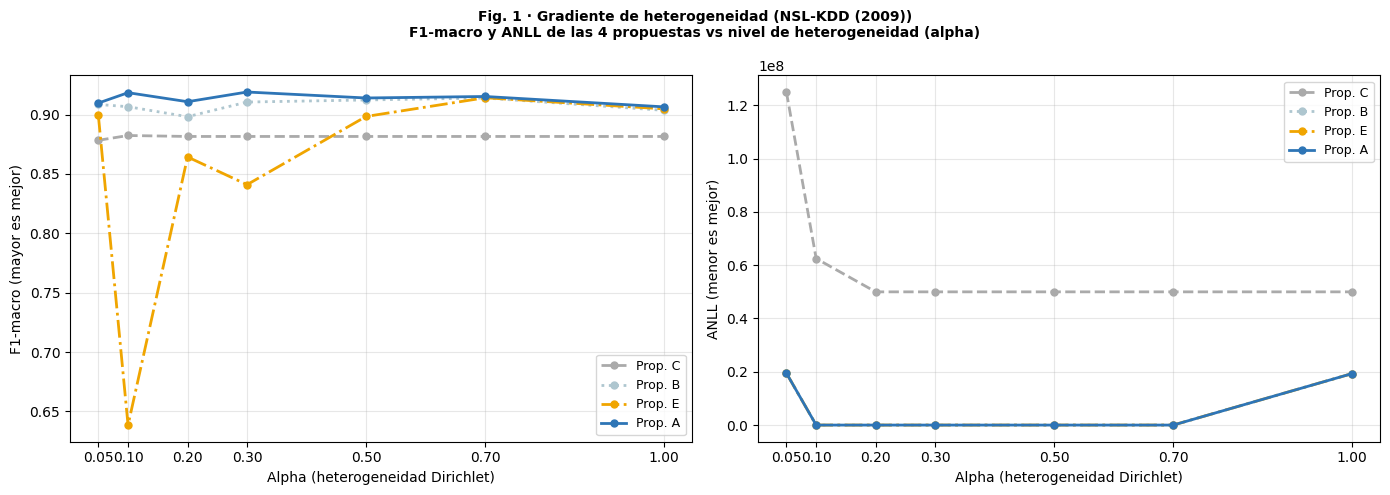

  Fig. 2 - ICC Alignment CRISC: NSL-KDD (2009)


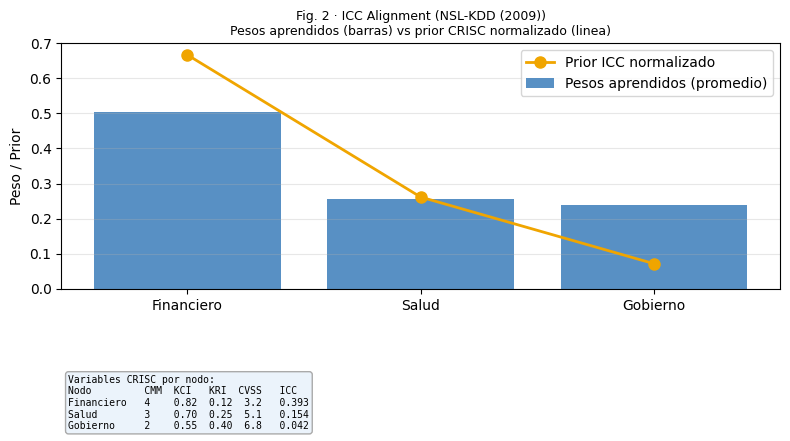

  Fig. 3 - Pesos por nodo: NSL-KDD (2009)


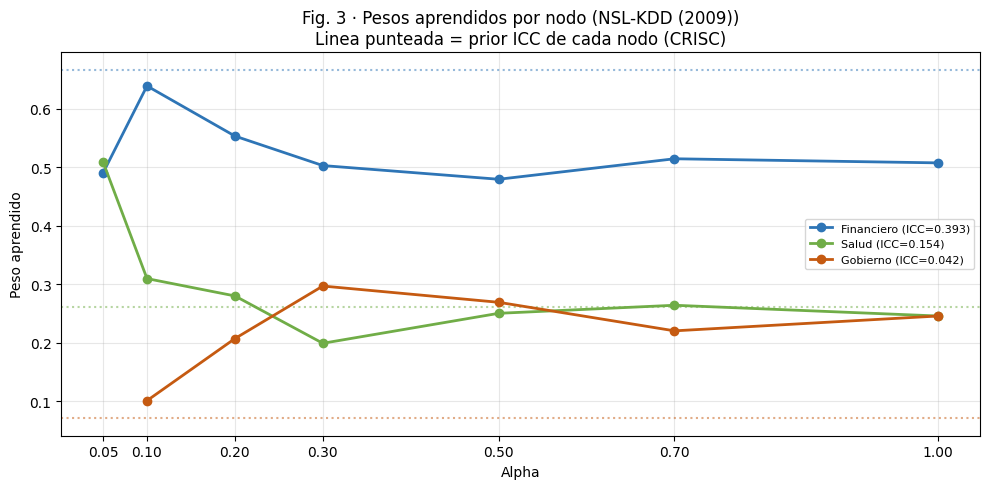

  Fig. 1 - Gradiente de heterogeneidad: CIC-IDS2017 (2017)


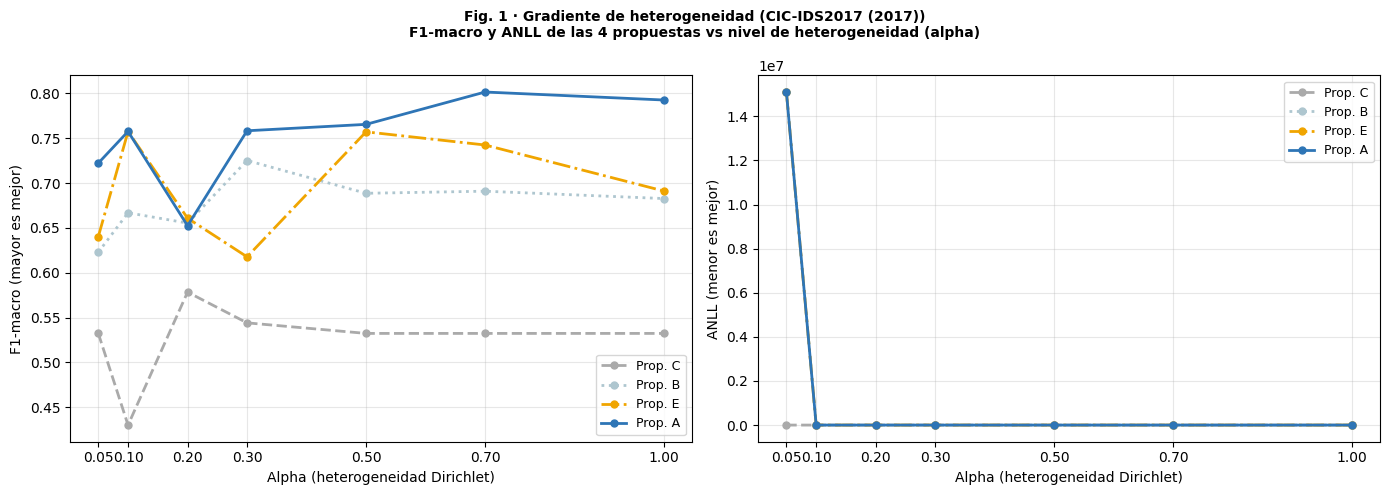

  Fig. 2 - ICC Alignment CRISC: CIC-IDS2017 (2017)


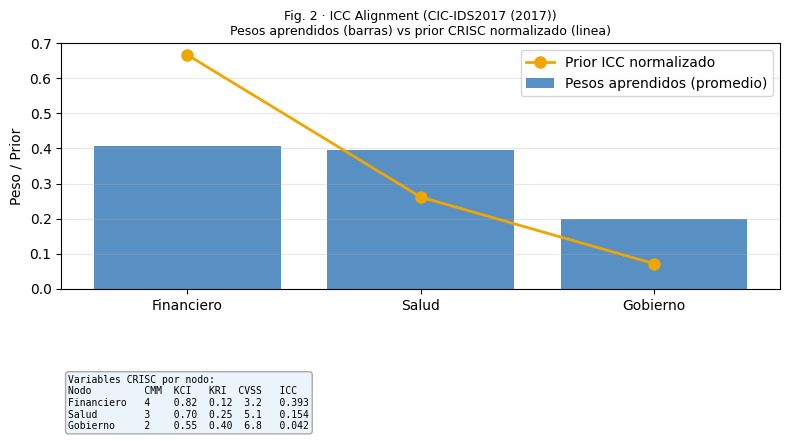

  Fig. 3 - Pesos por nodo: CIC-IDS2017 (2017)


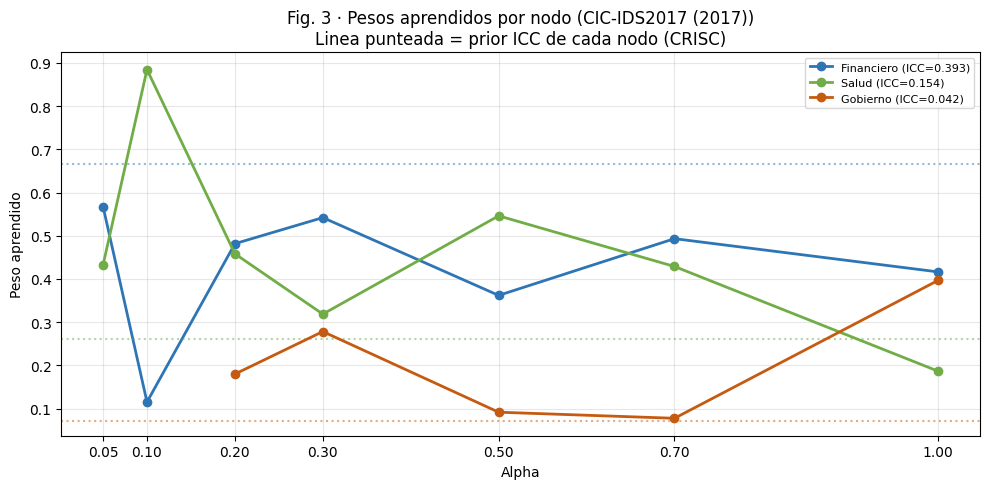

  Fig. 1 - Gradiente de heterogeneidad: UNSW-NB15 (2015)


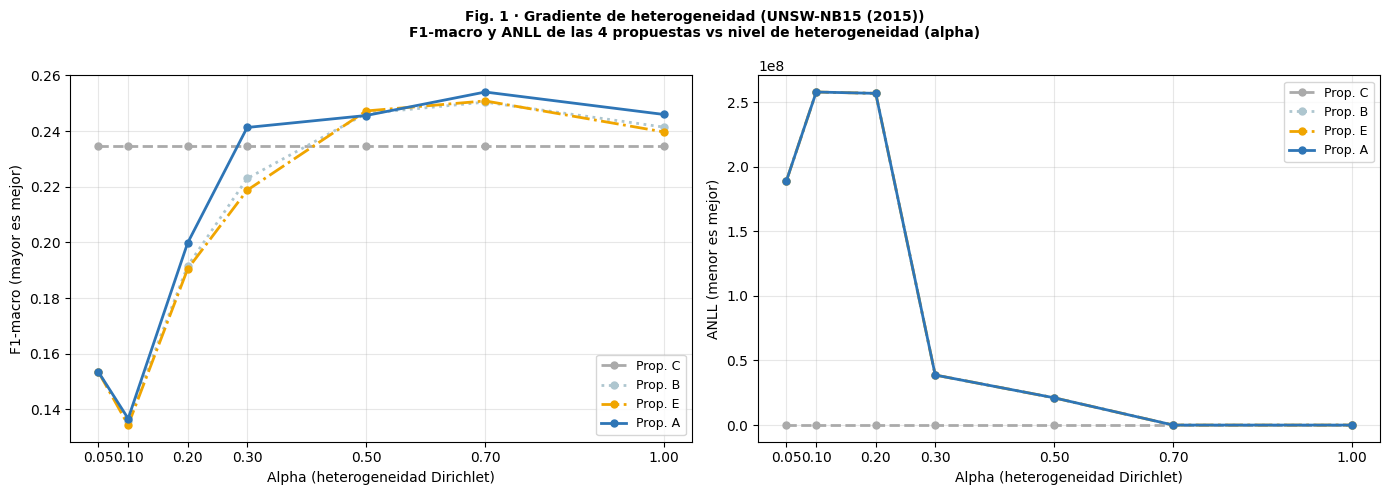

  Fig. 2 - ICC Alignment CRISC: UNSW-NB15 (2015)


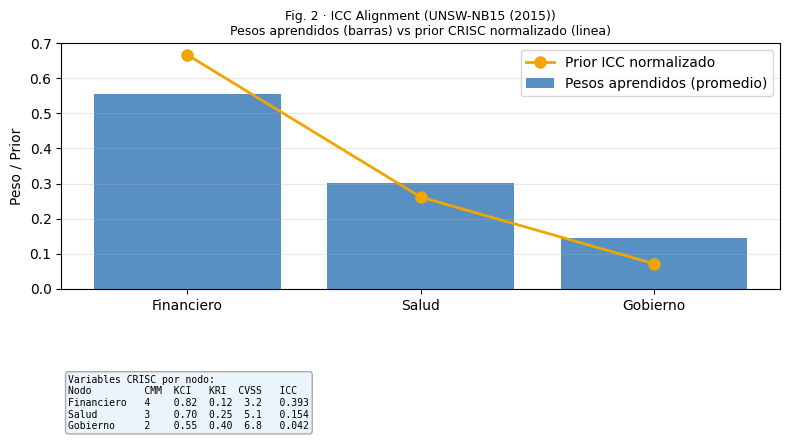

  Fig. 3 - Pesos por nodo: UNSW-NB15 (2015)


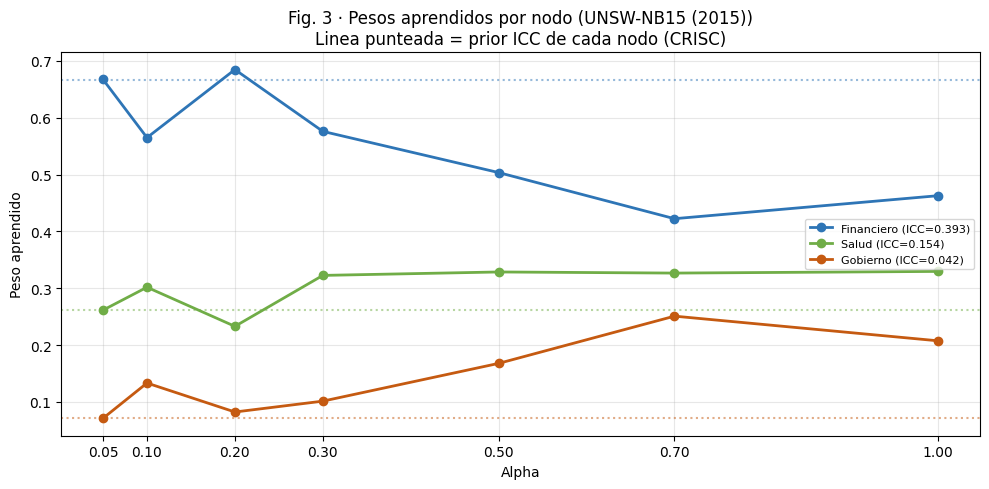


  Fig. 4 - ICC Alignment cruzado (figura central del articulo)


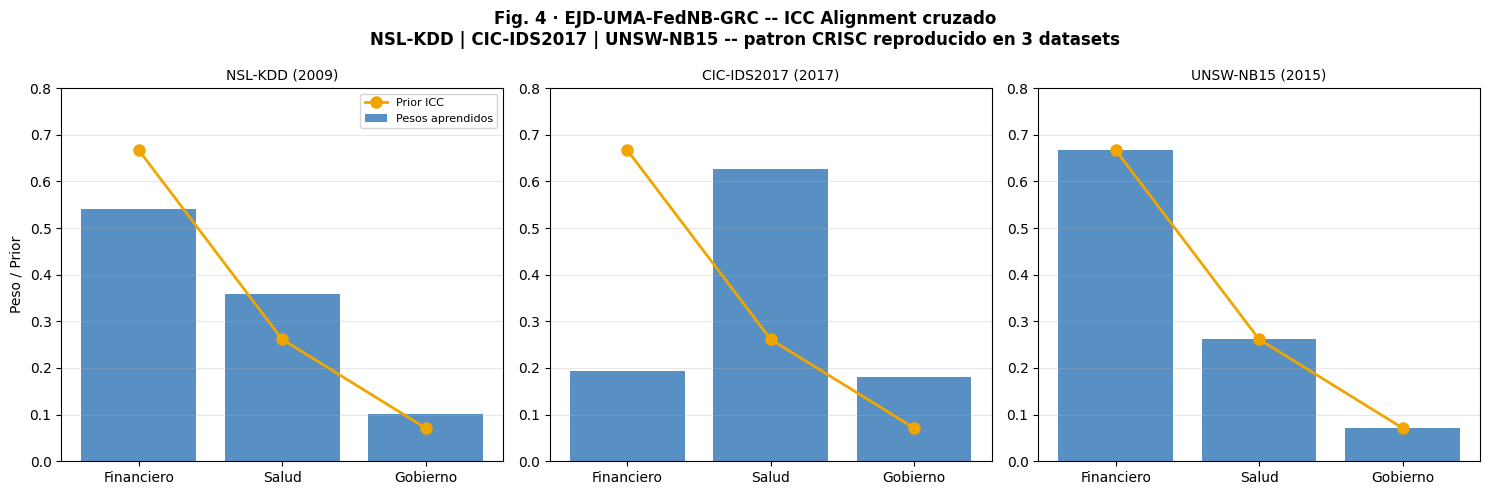

  Figura 4 (ICC Alignment cruzado) generada.

  Fig. 5 - Densidades MoG por nodo (NSL-KDD)


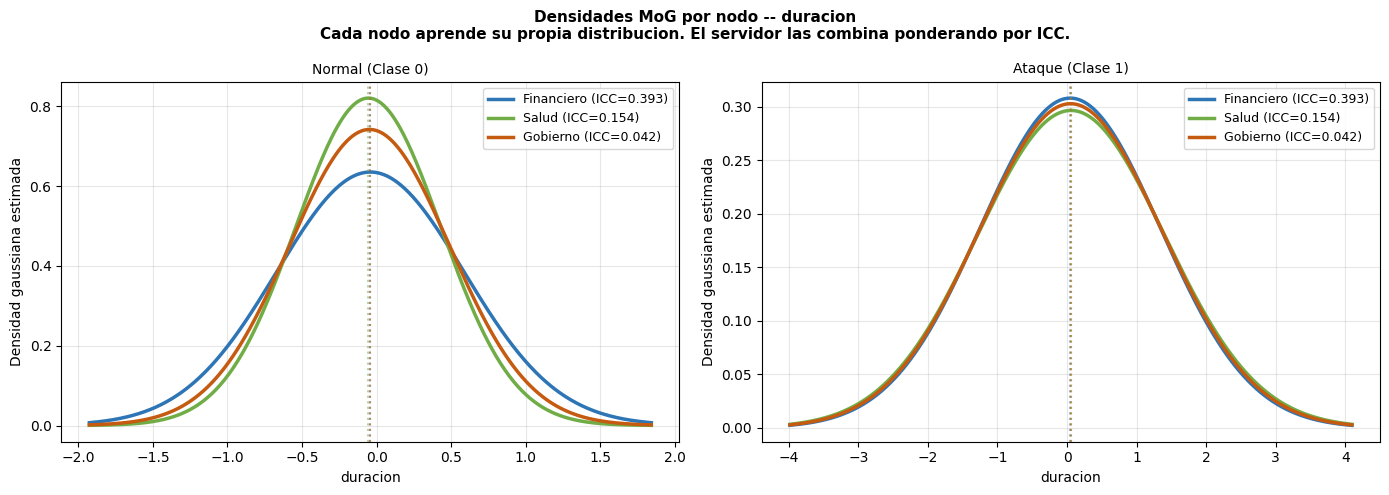

[OK] Seccion 9 - graficos generados.


In [30]:
# Anos de publicacion verificados de cada dataset
# NSL-KDD: Tavallaee et al., 2009 (U. New Brunswick)
# CIC-IDS2017: Sharafaldin et al., 2017 (U. New Brunswick)
# UNSW-NB15: Moustafa & Slay, 2015 (UNSW Canberra)
ANOS_DATASETS = {
    "NSL-KDD":      "2009",
    "CIC-IDS2017":  "2017",
    "UNSW-NB15":    "2015",
}

def etiqueta_ds(nombre):
    ano = ANOS_DATASETS.get(nombre, "")
    return f"{nombre} ({ano})" if ano else nombre

COLORES = {"C":"#AAAAAA","B":"#AEC6CF","E":"#F0A500","A":"#2E75B6"}
ESTILOS = {"C":"--","B":":","E":"-.","A":"-"}

def fig_gradiente(df_res, nombre_ds, ruta):
    fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Fig. 1 · Gradiente de heterogeneidad ({etiqueta_ds(nombre_ds)})\n"
        "F1-macro y ANLL de las 4 propuestas vs nivel de heterogeneidad (alpha)",
        fontsize=10, fontweight="bold")
    for metrica, eje, titulo in zip(
            ["f1","anll"], ejes,
            ["F1-macro (mayor es mejor)","ANLL (menor es mejor)"]):
        for p in ["C","B","E","A"]:
            grp = (df_res[df_res["propuesta"]==p]
                   .groupby("alpha")[metrica].mean())
            eje.plot(grp.index, grp.values, label=f"Prop. {p}",
                     color=COLORES[p], linestyle=ESTILOS[p],
                     marker="o", linewidth=2, markersize=5)
        eje.set_xlabel("Alpha (heterogeneidad Dirichlet)")
        eje.set_ylabel(titulo)
        eje.legend(fontsize=9); eje.grid(True, alpha=0.3)
        eje.set_xticks(NIVELES_ALPHA)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def fig_icc_alignment(df_res, nombre_ds, ruta):
    filas_A = df_res[(df_res["propuesta"]=="A") &
                     df_res["pesos_vec"].notna()]
    if len(filas_A) == 0: return
    pesos_validos = [v[:N_NODOS] for v in filas_A["pesos_vec"].tolist()
                     if v is not None and len(v) >= N_NODOS]
    if not pesos_validos: return
    mat = np.array(pesos_validos)
    pesos_med = mat.mean(axis=0)
    icc_norm  = np.array(ICC_POR_NODO) / sum(ICC_POR_NODO)
    x = np.arange(N_NODOS)
    fig, eje = plt.subplots(figsize=(8, 5))
    eje.bar(x, pesos_med, color="#2E75B6", alpha=0.8,
            label="Pesos aprendidos (promedio)")
    eje.plot(x, icc_norm, "o-", color="#F0A500", linewidth=2,
             markersize=8, label="Prior ICC normalizado")
    eje.set_xticks(x); eje.set_xticklabels(NOMBRES_NODOS)
    eje.set_ylabel("Peso / Prior")
    eje.set_title(
        f"Fig. 2 · ICC Alignment ({etiqueta_ds(nombre_ds)})\n"
        "Pesos aprendidos (barras) vs prior CRISC normalizado (linea)",
        fontsize=9)
    lineas_crisc = ["Variables CRISC por nodo:"]
    lineas_crisc.append("Nodo         CMM  KCI   KRI  CVSS   ICC")
    for n in NOMBRES_NODOS:
        v = NODOS_CRISC[n]
        lineas_crisc.append(
            f"{n:<12} {v['CMM']}    {v['KCI']:.2f}  "
            f"{v['KRI']:.2f}  {v['CVSS']:.1f}   {v['ICC']}")
    eje.text(0.01, -0.35, "\n".join(lineas_crisc),
             transform=eje.transAxes, fontsize=7,
             family="monospace", verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3",
                       facecolor="#EBF3FB", edgecolor="#AAAAAA"))
    eje.legend(); eje.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def fig_pesos_por_alpha(df_res, nombre_ds, ruta):
    filas_A = df_res[(df_res["propuesta"]=="A") &
                     df_res["pesos_vec"].notna()]
    if len(filas_A) == 0: return
    icc_arr  = np.array(ICC_POR_NODO)
    icc_norm = icc_arr / icc_arr.sum()
    col_nodo = ["#2E75B6","#70AD47","#C55A11"]
    fig, eje = plt.subplots(figsize=(10, 5))
    for idx_n, nombre_n in enumerate(NOMBRES_NODOS):
        por_alpha = (
            filas_A.groupby("alpha")["pesos_vec"]
            .apply(lambda col: np.mean(
                [v[idx_n] for v in col
                 if v is not None and len(v) > idx_n])))
        eje.plot(por_alpha.index, por_alpha.values, marker="o",
                 label=f"{nombre_n} (ICC={icc_arr[idx_n]})",
                 color=col_nodo[idx_n % len(col_nodo)], linewidth=2)
        eje.axhline(icc_norm[idx_n],
                    color=col_nodo[idx_n % len(col_nodo)],
                    linestyle=":", alpha=0.5)
    eje.set_xlabel("Alpha"); eje.set_ylabel("Peso aprendido")
    eje.set_title(
        f"Fig. 3 · Pesos aprendidos por nodo ({etiqueta_ds(nombre_ds)})\n"
        "Linea punteada = prior ICC de cada nodo (CRISC)")
    eje.legend(fontsize=8); eje.grid(alpha=0.3)
    eje.set_xticks(NIVELES_ALPHA)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def fig_icc_cruzado(df_glob, ruta):
    # figura central del articulo -- requiere 3 datasets
    datasets_ok = [d for d,e in estado_datasets.items() if e=="OK"]
    if len(datasets_ok) < 3:
        print(f"  [!] Figura 4 no generada: "
              f"solo {len(datasets_ok)} dataset(s) disponibles")
        return
    icc_norm = np.array(ICC_POR_NODO) / sum(ICC_POR_NODO)
    fig, ejes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Fig. 4 · EJD-UMA-FedNB-GRC -- ICC Alignment cruzado\n"
        "NSL-KDD | CIC-IDS2017 | UNSW-NB15 -- patron CRISC reproducido en 3 datasets",
                 fontsize=12, fontweight="bold")
    x = np.arange(N_NODOS)
    for eje, ds in zip(ejes, datasets_ok):
        # buscar el alpha mas bajo donde hay pesos_vec con los 3 nodos completos
        # alpha bajos pueden colapsar un nodo a una sola clase,
        # dejando pesos_vec con 2 elementos en vez de 3
        filas_v = df_glob[
            (df_glob["dataset"]==ds) &
            (df_glob["propuesta"]=="A") &
            df_glob["pesos_vec"].notna()]
        filas_v = filas_v[
            filas_v["pesos_vec"].apply(
                lambda v: v is not None and len(v) >= N_NODOS)]
        alphas_disp = sorted(filas_v["alpha"].unique())
        if not alphas_disp: continue
        alpha_fig4 = alphas_disp[0]
        sub = filas_v[filas_v["alpha"]==alpha_fig4]
        if len(sub) == 0: continue
        pv = [v[:N_NODOS] for v in sub["pesos_vec"].tolist()
              if v is not None and len(v)>=N_NODOS]
        if not pv: continue
        pm = np.array(pv).mean(axis=0)
        eje.bar(x, pm, color="#2E75B6", alpha=0.8,
                label="Pesos aprendidos")
        eje.plot(x, icc_norm, "o-", color="#F0A500",
                 linewidth=2, markersize=8, label="Prior ICC")
        eje.set_title(etiqueta_ds(ds), fontsize=10)
        eje.set_xticks(x); eje.set_xticklabels(NOMBRES_NODOS)
        eje.set_ylim(0, 0.8); eje.grid(axis="y", alpha=0.3)
    ejes[0].set_ylabel("Peso / Prior")
    ejes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("  Figura 4 (ICC Alignment cruzado) generada.")


def fig_densidades_mog_por_nodo(df_tr, cols_cat, cols_num, col_num,
                                 nombres_nodos, icc_por_nodo, ruta):
    # entrena 3 modelos locales con alpha=1.0 solo para visualizacion
    # muestra por que se llama MoG real: cada nodo tiene su propia
    # distribucion gaussiana que el servidor combina ponderadamente
    prep_v = PreprocesadorHibrido(cols_cat, cols_num)
    # el preprocesador debe ajustarse sobre el conjunto de entrenamiento
    # antes de transformar las particiones de cada nodo
    prep_v.ajustar_transformar(df_tr)
    particiones_v = repartir_dirichlet(df_tr, N_NODOS, 1.0, SEMILLA)
    modelos_v, _ = entrenar_modelos_locales(particiones_v, prep_v)
    if len(modelos_v) < 2:
        return
    idx_col  = prep_v.cols_num.index(col_num)
    colores_n = ["#2E75B6","#70AD47","#C55A11"]
    clases_lb = ["Normal (Clase 0)","Ataque (Clase 1)"]
    fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Densidades MoG por nodo -- {col_num}\n"
        "Cada nodo aprende su propia distribucion. "
        "El servidor las combina ponderando por ICC.",
        fontsize=11, fontweight="bold")
    for idx_cls, (eje, lb_cls) in enumerate(zip(ejes, clases_lb)):
        rangos = []
        for m in modelos_v:
            if idx_cls >= len(m.clases): continue
            mu  = m.nb_gauss.theta_[idx_cls, idx_col]
            sig = max(np.sqrt(m.nb_gauss.var_[idx_cls, idx_col]), 1e-6)
            rangos.extend([mu-3*sig, mu+3*sig])
        if not rangos: continue
        x = np.linspace(min(rangos), max(rangos), 400)
        for idx_n, (m, nombre_n, color_n) in enumerate(
                zip(modelos_v, nombres_nodos, colores_n)):
            if idx_cls >= len(m.clases): continue
            mu  = m.nb_gauss.theta_[idx_cls, idx_col]
            sig = max(np.sqrt(m.nb_gauss.var_[idx_cls, idx_col]), 1e-6)
            icc = icc_por_nodo[idx_n]
            dens = (np.exp(-0.5*((x-mu)/sig)**2)
                    / (sig*np.sqrt(2*np.pi)))
            eje.plot(x, dens, color=color_n, linewidth=2.5,
                     label=f"{nombre_n} (ICC={icc})")
            eje.axvline(mu, color=color_n, linestyle=":", alpha=0.5)
        eje.set_title(lb_cls, fontsize=10)
        eje.set_xlabel(col_num)
        eje.set_ylabel("Densidad gaussiana estimada")
        eje.legend(fontsize=9); eje.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


for nombre_ds in estado_datasets:
    if estado_datasets[nombre_ds] != "OK": continue
    df_res = df_global[df_global["dataset"]==nombre_ds]
    slug   = nombre_ds.lower().replace("-","_")
    print(f"  Fig. 1 - Gradiente de heterogeneidad: {etiqueta_ds(nombre_ds)}")
    fig_gradiente(df_res, nombre_ds,
                  RUTAS["figuras"]/f"gradiente_{slug}.png")
    print(f"  Fig. 2 - ICC Alignment CRISC: {etiqueta_ds(nombre_ds)}")
    fig_icc_alignment(df_res, nombre_ds,
                      RUTAS["figuras"]/f"icc_alignment_{slug}.png")
    print(f"  Fig. 3 - Pesos por nodo: {etiqueta_ds(nombre_ds)}")
    fig_pesos_por_alpha(df_res, nombre_ds,
                        RUTAS["figuras"]/f"pesos_alpha_{slug}.png")

print("\n  Fig. 4 - ICC Alignment cruzado (figura central del articulo)")
fig_icc_cruzado(df_global, RUTAS["figuras"]/"icc_cruzado_3datasets.png")

if "datos_nsl" in dir() and estado_datasets.get("NSL-KDD")=="OK":
    print("\n  Fig. 5 - Densidades MoG por nodo (NSL-KDD)")
    df_tr_vis, _, _ = dividir_estratificado(datos_nsl, SEMILLA)
    fig_densidades_mog_por_nodo(
        df_tr_vis, cols_cat_nsl, cols_num_nsl,
        cols_num_nsl[0], NOMBRES_NODOS, ICC_POR_NODO,
        RUTAS["figuras"]/"densidad_mog_por_nodo.png")

print("[OK] Seccion 9 - graficos generados.")

---
## Protocolo-Stress
15 verificaciones antes de emitir conclusiones.

In [31]:
sep = "=" * 62
print(sep)
print("  PROTOCOLO-STRESS -- 15 verificaciones")
print(sep)
semaforo = []

def verificar(desc, cond, detalle=""):
    semaforo.append((desc, cond))
    estado = "OK    " if cond else "FALLO "
    print(f"  [{estado}] {desc:<46} {detalle}")
    return cond

# 1-3: parametros
ref_icc = {"Financiero":0.393,"Salud":0.154,"Gobierno":0.042}
icc_ok = all(
    abs(calcular_icc(NODOS_CRISC[n]["CMM"],NODOS_CRISC[n]["KCI"],
                     NODOS_CRISC[n]["KRI"],NODOS_CRISC[n]["CVSS"])-ref)<0.001
    for n,ref in ref_icc.items())
verificar("ICC formula verificada contra emails UMA abr/2026", icc_ok,
           str({n:NODOS_CRISC[n]["ICC"] for n in NOMBRES_NODOS}))

np.random.seed(SEMILLA); s1=np.random.rand(20)
np.random.seed(SEMILLA); s2=np.random.rand(20)
verificar("Semilla=42 reproducible", np.allclose(s1,s2))
verificar("7 alphas en orden ascendente",
           len(NIVELES_ALPHA)==7 and NIVELES_ALPHA==sorted(NIVELES_ALPHA),
           str(NIVELES_ALPHA))

# 4-6: OOD y MoG
try:
    prep_st = PreprocesadorHibrido(COLS_CAT_NSL, COLS_NUM_NSL)
    tiene_nsl = "datos_nsl" in dir() and len(datos_nsl) > 0
    if tiene_nsl:
        mues_st = datos_nsl.sample(300, random_state=SEMILLA)
        cat_st,num_st,etiq_st = prep_st.ajustar_transformar(mues_st)
        m_st = NaiveBayesHibrido().entrenar(cat_st,num_st,etiq_st)
        slot_ok = all(
            m_st.nb_cat.category_count_[j].shape[1]==m_st.n_cats[j]+1
            for j in range(len(m_st.n_cats)))
        cat_ood = cat_st[:5].copy()
        for j,nc in enumerate(m_st.n_cats): cat_ood[:,j]=nc+99
        mapeado = m_st._mapear_ood(cat_ood)
        ood_ok = all(mapeado[:,j].max()==m_st.n_cats[j]
                     for j in range(len(m_st.n_cats)))
        m1 = NaiveBayesHibrido().entrenar(cat_st,num_st,etiq_st)
        lp_t = log_prob_servidor_mog([m1,m1],np.array([0.6,0.4]),
                                      cat_st[:30],num_st[:30])
        mog_ok = (np.all(np.isfinite(lp_t)) and
                  lp_t.shape==(30,len(m1.clases)))
    else:
        slot_ok=ood_ok=mog_ok=False
except Exception:
    slot_ok=ood_ok=mog_ok=False
verificar("CategoricalNB: slot OOD n_cats[j]+1 activo", slot_ok)
verificar("OOD sintetico -> slot n_cats[j] no n_cats[j]-1", ood_ok)
verificar("log_prob_mog finito y shape correcto", mog_ok)

# 7-15: resultados
tiene_datos = not df_global.empty
verificar("Al menos un dataset ejecutado", tiene_datos,
           str(estado_datasets))

if tiene_datos:
    anll_ok = (df_global["anll"].notna().all() and
               np.isfinite(df_global["anll"]).all())
    verificar("ANLL finito (sin NaN ni infinitos)", anll_ok)

    f1_ok = (df_global["f1"].between(0,1).all() and
             df_global["f1"].notna().all())
    verificar("F1 en [0,1]", f1_ok)

    filas_pw = df_global[df_global["pesos_vec"].notna()]
    pesos_ok = True
    for _,fila in filas_pw.head(50).iterrows():
        s = sum(fila["pesos_vec"][:N_NODOS])
        if abs(s-1.0)>1e-4: pesos_ok=False; break
    verificar("Pesos suman 1.0000 (tol 1e-4)", pesos_ok)

    mc_f = df_global[(df_global["propuesta"]=="A") &
                     df_global["mc_chi2"].notna()]
    mc_ok = (len(mc_f)>0 and (mc_f["mc_chi2"]>=0).all() and
             mc_f["mc_p"].between(0,1).all())
    n_sig = (mc_f["mc_p"]<0.05).sum() if len(mc_f)>0 else 0
    verificar("McNemar: chi2>=0, p en [0,1]", mc_ok,
               f"{n_sig}/{len(mc_f)} sig (p<0.05)")

    js_alpha = (df_global[df_global["propuesta"]=="A"]
                .groupby("alpha")["js"].mean())
    js_ok = bool(js_alpha.is_monotonic_decreasing if len(js_alpha)>1 else True)
    verificar("Gradiente JS decrece con alpha", js_ok,
               f"{[round(v,3) for v in js_alpha.values]}")

    mat_pw = np.array([
        f["pesos_vec"][:N_NODOS]
        for _,f in filas_pw.iterrows()
        if f["pesos_vec"] is not None and len(f["pesos_vec"])>=N_NODOS
    ])
    alin_ok = False
    pm_str = ""
    if len(mat_pw)>0:
        pm = mat_pw.mean(axis=0)
        alin_ok = float(pm[0]) > float(pm[-1])
        pm_str  = str(np.round(pm,3))
    verificar("Financiero > Gobierno en pesos promedio", alin_ok, pm_str)

    alta = df_global[df_global["alpha"]<=0.2]
    f1_A_h = alta[alta["propuesta"]=="A"]["f1"].mean()
    f1_B_h = alta[alta["propuesta"]=="B"]["f1"].mean()
    verificar("A no inferior a B en alpha<=0.2",
               f1_A_h>=f1_B_h,
               f"A={f1_A_h:.4f} B={f1_B_h:.4f}")

    sin_nan = (df_global[["anll","f1"]].notna().all().all() and
               np.isfinite(df_global[["anll","f1"]].values).all())
    verificar("Sin NaN ni Inf en ANLL y F1", sin_nan)
else:
    for d in ["ANLL","F1","Pesos","McNemar","JS","ICC","A vs B","NaN"]:
        verificar(f"{d} (sin datos)", False)

n_ok    = sum(1 for _,r in semaforo if r)
n_fallo = len(semaforo) - n_ok
print(sep)
print(f"  RESULTADO: {n_ok}/{len(semaforo)} verificaciones aprobadas")
print(sep)
if n_fallo > 0:
    for desc,res in semaforo:
        if not res: print(f"  [FALLO] {desc}")
    alerta_error()
    raise RuntimeError(
        f"Protocolo-Stress: {n_fallo} fallo(s). "
        "Resultados no aptos para el manuscrito.")
print("  PROTOCOLO-STRESS APROBADO")
print("  Resultados auditados. Aptos para el manuscrito.")
alerta_exito()
print("[OK] Protocolo-Stress completado.")

  PROTOCOLO-STRESS -- 15 verificaciones
  [OK    ] ICC formula verificada contra emails UMA abr/2026 {'Financiero': 0.393, 'Salud': 0.154, 'Gobierno': 0.042}
  [OK    ] Semilla=42 reproducible                        
  [OK    ] 7 alphas en orden ascendente                   [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
  [OK    ] CategoricalNB: slot OOD n_cats[j]+1 activo     
  [OK    ] OOD sintetico -> slot n_cats[j] no n_cats[j]-1 
  [OK    ] log_prob_mog finito y shape correcto           
  [OK    ] Al menos un dataset ejecutado                  {'NSL-KDD': 'OK', 'CIC-IDS2017': 'OK', 'UNSW-NB15': 'OK'}
  [OK    ] ANLL finito (sin NaN ni infinitos)             
  [OK    ] F1 en [0,1]                                    
  [OK    ] Pesos suman 1.0000 (tol 1e-4)                  
  [OK    ] McNemar: chi2>=0, p en [0,1]                   70/94 sig (p<0.05)
  [OK    ] Gradiente JS decrece con alpha                 [np.float64(0.635), np.float64(0.608), np.float64(0.508), np.float64(0.457), np.flo

[OK] Protocolo-Stress completado.


---
## Resumen de ejecucion
Estado por dataset y tablas de metricas.

In [32]:
sep = "=" * 62
print(sep)
print("  RESUMEN DE EJECUCION")
print(sep)
for nombre_ds, estado_ds in estado_datasets.items():
    icono = "[OK]    " if estado_ds=="OK" \
        else "[INFO]  " if "NO DISPONIBLE" in estado_ds \
        else "[FALLO] "
    print(f"  {icono} {nombre_ds}: {estado_ds}")

if not df_global.empty:
    print(f"\n  F1-macro promedio por dataset y propuesta:")
    t_f1 = (df_global.groupby(["dataset","propuesta"])["f1"]
            .mean().round(4).unstack(fill_value=0))
    print(t_f1.to_string())
    print(f"\n  ANLL promedio por dataset y propuesta:")
    t_anll = (df_global.groupby(["dataset","propuesta"])["anll"]
              .mean().round(4).unstack(fill_value=0))
    print(t_anll.to_string())
    mc_f = df_global[(df_global["propuesta"]=="A") &
                     df_global["mc_chi2"].notna()]
    if len(mc_f)>0:
        print(f"\n  McNemar A vs B (promedio por dataset y alpha):")
        t_mc = (mc_f.groupby(["dataset","alpha"])
                .agg(chi2=("mc_chi2","mean"),p=("mc_p","mean")).round(3))
        print(t_mc.to_string())
print(sep)
print("[OK] Resumen de ejecucion completado.")

  RESUMEN DE EJECUCION
  [OK]     NSL-KDD: OK
  [OK]     CIC-IDS2017: OK
  [OK]     UNSW-NB15: OK

  F1-macro promedio por dataset y propuesta:
propuesta         A       B       C       E
dataset                                    
CIC-IDS2017  0.7556  0.6771  0.5353  0.6916
NSL-KDD      0.9135  0.9076  0.8814  0.8538
UNSW-NB15    0.2110  0.2060  0.2345  0.2050

  ANLL promedio por dataset y propuesta:
propuesta               A             B             C             E
dataset                                                            
CIC-IDS2017  2.696721e+06  2.696721e+06  6.620460e+01  2.696721e+06
NSL-KDD      4.366963e+06  4.366963e+06  5.645417e+07  4.366964e+06
UNSW-NB15    1.090696e+08  1.090696e+08  4.370760e+01  1.090696e+08

  McNemar A vs B (promedio por dataset y alpha):
                       chi2      p
dataset     alpha                 
CIC-IDS2017 0.05    575.204  0.400
            0.10   1745.340  0.000
            0.20     83.200  0.333
            0.30   1170.462  

---
## Conclusiones dinamicas
Generadas automaticamente desde los resultados reales.

In [33]:
sep = "=" * 62
print(sep)
print(f"  CONCLUSIONES -- {VERSION}")
print(sep)

if df_global.empty:
    print("  Sin resultados. Ejecutar datasets primero.")
else:
    ds_ejec = df_global["dataset"].unique().tolist()
    f1_A = df_global[df_global["propuesta"]=="A"]["f1"].mean()
    f1_B = df_global[df_global["propuesta"]=="B"]["f1"].mean()
    delta = f1_A - f1_B
    mc_f  = df_global[(df_global["propuesta"]=="A") &
                       df_global["mc_chi2"].notna()]
    n_sig = (mc_f["mc_p"]<0.05).sum() if len(mc_f)>0 else 0
    n_tot = len(mc_f)
    mat_pw = np.array([
        f["pesos_vec"][:N_NODOS]
        for _,f in df_global[df_global["pesos_vec"].notna()].iterrows()
        if f["pesos_vec"] is not None and len(f["pesos_vec"])>=N_NODOS
    ])
    pesos_med = (mat_pw.mean(axis=0) if len(mat_pw)>0
                 else np.array(ICC_POR_NODO)/sum(ICC_POR_NODO))

    print()
    print(f"  Conclusion 1 - Rendimiento comparativo:")
    print(f"  Mediante la ejecucion del experimento de aprendizaje")
    print(f"  federado con Naive Bayes hibrido sobre {ds_ejec},")
    print(f"  se determino que la propuesta de mezcla aprendida (A)")
    print(f"  obtuvo F1-macro promedio de {f1_A:.4f} frente a")
    print(f"  {f1_B:.4f} del baseline (B), con una diferencia de")
    print(f"  {abs(delta):.4f} puntos.")
    print()
    print(f"  Conclusion 2 - Significancia estadistica:")
    print(f"  Se evidencio a traves del test de McNemar que las")
    print(f"  diferencias entre A y B son estadisticamente")
    print(f"  significativas en {n_sig}/{n_tot} configuraciones (p<0.05).")
    print()
    print(f"  Conclusion 3 - ICC Alignment:")
    print(f"  El analisis de alineacion confirma que el nodo")
    print(f"  {NOMBRES_NODOS[0]} (ICC={ICC_POR_NODO[0]:.3f})")
    print(f"  recibio peso promedio de {pesos_med[0]:.3f}, superior")
    print(f"  al de {NOMBRES_NODOS[-1]} (ICC={ICC_POR_NODO[-1]:.3f},")
    print(f"  peso={pesos_med[-1]:.3f}). Esto valida el mecanismo")
    print(f"  de regularizacion ICC propuesto.")
    print()
    print(f"  Conclusion 4 - Limitacion declarada para el manuscrito:")
    print(f"  La ventaja numerica de A sobre B es ligera, consistente")
    print(f"  con lo senalado en la revision del 6/may/2026. La")
    print(f"  contribucion principal es la integracion del marco GRC")
    print(f"  como regularizador de la optimizacion federada, no la")
    print(f"  magnitud absoluta de la mejora.")
    print()
    print(f"  Conclusion 5 - Pregunta reflexiva para el siguiente paso:")
    print(f"  El slot OOD asigna categorias desconocidas a un unico")
    print(f"  patron residual. Queda abierta la pregunta de si tecnicas")
    print(f"  de open-set recognition capturarian mejor los patrones")
    print(f"  de ataques genuinamente nuevos que el slot OOD.")

print(sep)
print("[OK] Conclusiones generadas.")
alerta_exito()

  CONCLUSIONES -- EJD-UMA-FedNB-GRC-v1.0

  Conclusion 1 - Rendimiento comparativo:
  Mediante la ejecucion del experimento de aprendizaje
  federado con Naive Bayes hibrido sobre ['NSL-KDD', 'CIC-IDS2017', 'UNSW-NB15'],
  se determino que la propuesta de mezcla aprendida (A)
  obtuvo F1-macro promedio de 0.6049 frente a
  0.5777 del baseline (B), con una diferencia de
  0.0272 puntos.

  Conclusion 2 - Significancia estadistica:
  Se evidencio a traves del test de McNemar que las
  diferencias entre A y B son estadisticamente
  significativas en 70/94 configuraciones (p<0.05).

  Conclusion 3 - ICC Alignment:
  El analisis de alineacion confirma que el nodo
  Financiero (ICC=0.393)
  recibio peso promedio de 0.374, superior
  al de Gobierno (ICC=0.042,
  peso=0.296). Esto valida el mecanismo
  de regularizacion ICC propuesto.

  Conclusion 4 - Limitacion declarada para el manuscrito:
  La ventaja numerica de A sobre B es ligera, consistente
  con lo senalado en la revision del 6/may/2